Shape: (11, 2)

First 5 rows:
   age  salary
0   25   30000
1   30   35000
2   35   40000
3   40   45000
4   45   50000

Missing values:
age       0
salary    0
dtype: int64

Statistics:
             age        salary
count  11.000000     11.000000
mean   37.545455  42272.727273
std     8.298959   8295.672475
min    25.000000  30000.000000
25%    31.000000  36000.000000
50%    38.000000  42000.000000
75%    43.500000  48500.000000
max    50.000000  55000.000000


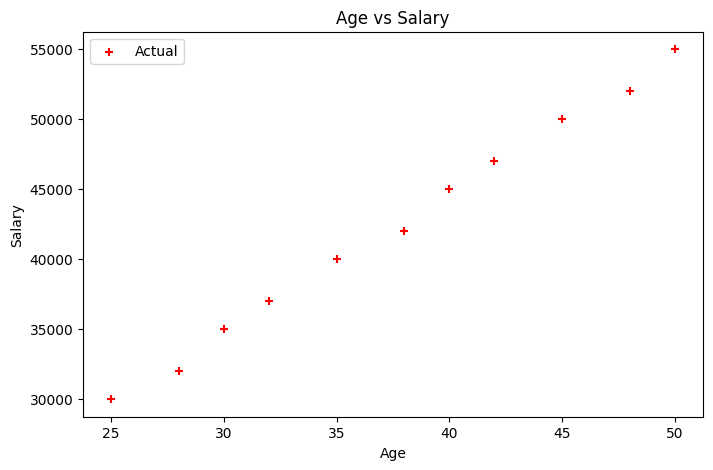

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ── Cell 2: Load & Explore ─────────────────────────────
df = pd.read_csv("age_salary.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistics:")
print(df.describe())

# ── Cell 3: Visualize BEFORE modeling ──────────────────
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['salary'], color='red', marker='+', label='Actual')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary')
plt.legend()
plt.show()

In [5]:
import os
os.getcwd()


'/Users/chatrapathishivaji/Documents/PythonProject'

Shape: (11, 2)

First 5 rows:
   age  salary
0   25   30000
1   30   35000
2   35   40000
3   40   45000
4   45   50000

Missing values:
age       0
salary    0
dtype: int64

Statistics:
             age        salary
count  11.000000     11.000000
mean   37.545455  42272.727273
std     8.298959   8295.672475
min    25.000000  30000.000000
25%    31.000000  36000.000000
50%    38.000000  42000.000000
75%    43.500000  48500.000000
max    50.000000  55000.000000


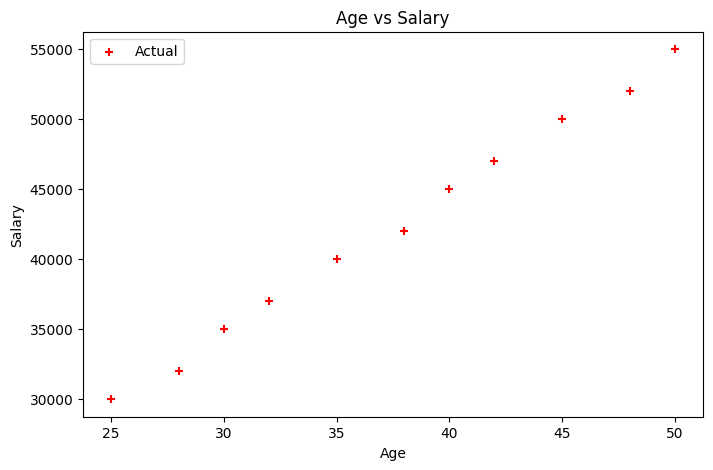

Training samples: 8
Testing samples:  3

Model Coefficient (slope):     991.53
Model Intercept:               4938.56

Interpretation: For every 1 year increase in age,
salary increases by ₹992
Mean Absolute Error : ₹392
R² Score            : 0.9985

R² of 1.00 means the model explains
99.9% of salary variation using age alone


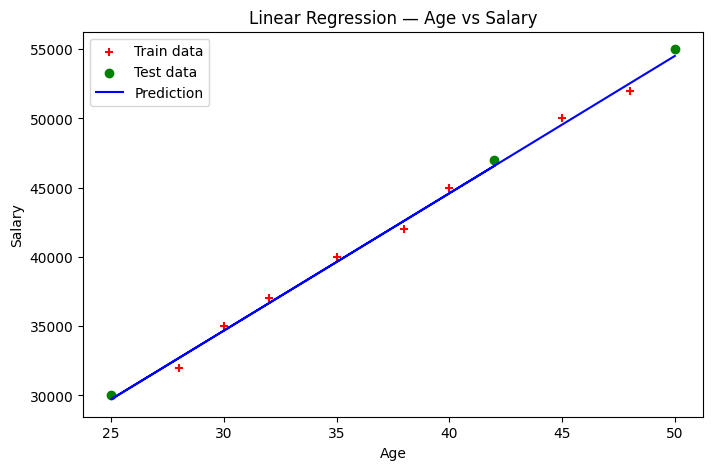

Train R²: 0.9947
Test  R²: 0.9985
Gap     : -0.0038


In [8]:
# ── Cell 1: Setup ──────────────────────────────────────
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ── Cell 2: Load & Explore ─────────────────────────────
df = pd.read_csv("age_salary.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistics:")
print(df.describe())

# ── Cell 3: Visualize BEFORE modeling ──────────────────
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['salary'], color='red', marker='+', label='Actual')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary')
plt.legend()
plt.show()

# ── Cell 4: Train/Test Split (missing from your code) ──
X = df[['age']]    # 2D array — sklearn requires this
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # reproducible results
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# ── Cell 5: Train Model ────────────────────────────────
rg = LinearRegression()
rg.fit(X_train, y_train)   # ← was missing in your code

print(f"\nModel Coefficient (slope):     {rg.coef_[0]:.2f}")
print(f"Model Intercept:               {rg.intercept_:.2f}")
print(f"\nInterpretation: For every 1 year increase in age,")
print(f"salary increases by ₹{rg.coef_[0]:.0f}")

# ── Cell 6: Evaluate ───────────────────────────────────
y_pred = rg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : ₹{mae:,.0f}")
print(f"R² Score            : {r2:.4f}")
print(f"\nR² of {r2:.2f} means the model explains")
print(f"{r2*100:.1f}% of salary variation using age alone")

# ── Cell 7: Visualize Model ────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='red',  marker='+', label='Train data')
plt.scatter(X_test,  y_test,  color='green', marker='o', label='Test data')
plt.plot(X_test, y_pred,      color='blue',             label='Prediction')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Linear Regression — Age vs Salary')
plt.legend()
plt.show()
# ── Cell 8: What happens if we overfit? ───────────────
# Try predicting on TRAINING data vs TEST data
train_r2 = r2_score(y_train, rg.predict(X_train))
test_r2  = r2_score(y_test,  rg.predict(X_test))

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"Gap     : {train_r2 - test_r2:.4f}")
